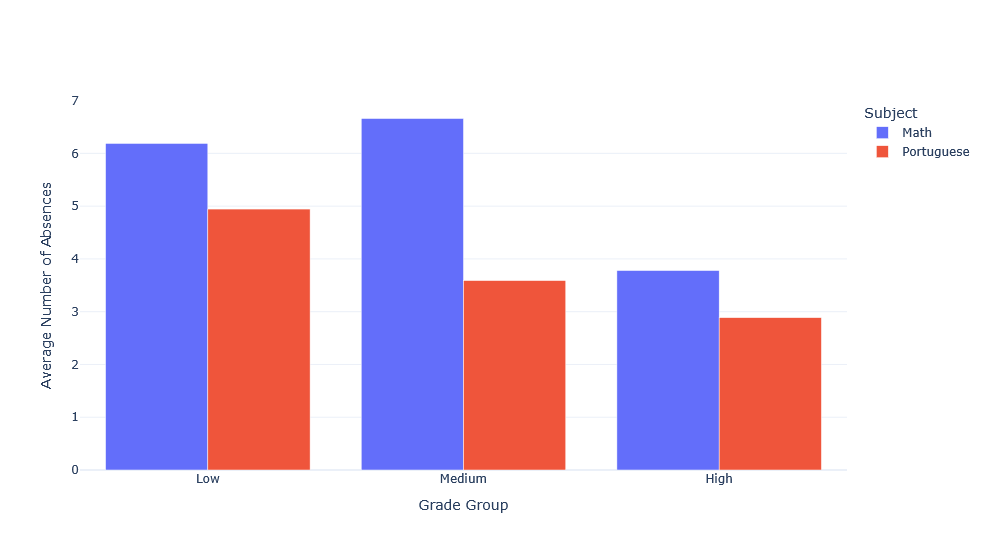

In [2]:
import pandas as pd
import plotly.graph_objects as go

# Load Dataset 3
df3_mat = pd.read_csv("../../data/student-mat.csv", sep=None, engine="python")
df3_por = pd.read_csv("../../data/student-por.csv", sep=None, engine="python")

# Combine Math and Portuguese
df3_mat["Subject"] = "Math"
df3_por["Subject"] = "Portuguese"
df3 = pd.concat([df3_mat, df3_por], ignore_index=True)

# Create balanced Grade Group
def add_grade_group(df, grade_col):
    df = df.copy()
    df["Grade Group"] = pd.qcut(
        df[grade_col].rank(method="first"),
        q=3,
        labels=["Low", "Medium", "High"]
    )
    return df

df3 = add_grade_group(df3, "G3")

grade_order = ["Low", "Medium", "High"]

# Average absences by grade group and subject
s3 = (
    df3.groupby(["Grade Group", "Subject"], observed=False)["absences"]
    .mean()
    .reset_index()
)

# Figure
fig = go.Figure()

for subject in ["Math", "Portuguese"]:
    temp = (
        s3[s3["Subject"] == subject]
        .set_index("Grade Group")
        .reindex(grade_order)
    )

    fig.add_trace(
        go.Bar(
            x=grade_order,
            y=temp["absences"],
            name=subject
        )
    )

fig.update_layout(
    barmode="group",
    height=550,
    width=950,
    template="plotly_white",
    legend_title_text="Subject",
    xaxis_title="Grade Group",
    yaxis_title="Average Number of Absences"
)

fig.show(config={"displayModeBar": False})
